In [1]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 5.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [9]:
dlx_list = ['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2','Gpc4', 'Eif1b']

In [10]:
nfix_list = ['Chd7','Adamtsl3','Gpd1','Cd9','Htr3a','P2rx7','Rnf141','Fdxr','Abcb8','Lama4']

In [11]:
uncx_list = ['Tmem163','Slc17a6','Cacna2d1','Nrn1','Mab21l2','Chst8','Tmem229b','F13a1','Fras1','Epb41l4a']

In [12]:
pgr_list = ['Prlr','Svop','Smarcc2','Sin3b','Gpd1l','Crim1','Gria1','Cdh4','Cadps2','Crmp1']

In [26]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [27]:
scenic = pd.read_csv('../../eRegulon_direct_guang.tsv', delimiter = '\t')

In [2]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
sam_mg = SAM()
sam_mg.load_data('../../Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [4]:
sam_mo = SAM()
sam_mo.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [5]:
sam_cj = SAM()
sam_cj.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [6]:
sam_ac= SAM()
sam_ac.load_data('../../Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_03122025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [7]:
sam_xt = SAM()
sam_xt.load_data('../../Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_03122205.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [8]:
sam_dr = SAM()
sam_dr.load_data('../../Active_SAM_joined/SAM_DR_ncbi_joined_cleaned_07172026.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [9]:
TF = pd.read_csv('../../Fin_TF_06012026.csv')
TF_set = set(TF['0'])

In [10]:
otohomo = pd.read_csv('../../OTO_star_nothreshold_6species_ohnlogs_expressionthresh_08022026.tsv',delimiter = '\t', index_col = 'MM')

In [14]:
orthogroups = pd.read_csv('../../Vert_emapper_allorgs_08012026.tsv', delimiter = '\t',index_col = 'Unnamed: 0')
mm_mapping_ortho = orthogroup_mapper(orthogroups, 'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups, 'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups, 'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups, 'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups, 'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [15]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [16]:
#to ensure that you only get hypothalamic cell types
with open('../../parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item[:2] == 'mo' or item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'
        
for item in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique():
    if item[:2] == 'cj' or item[:2] == 'mg' or item[:2] == 'ac' or item[:2] == 'xt' or item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    elif item[-2:] == 'NN':
        parent_dict[item] = 'not hypo'

In [17]:
parent_dict['hypo'] = 'hypo'
parent_dict['not hypo'] = 'not hypo'

In [18]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [19]:
overall_TF_set = set(otohomo.index) & TF_set

In [64]:
test_genes = ['Pgr', 'Ar']

In [65]:
a = 0
for item in test_genes:
    if item in overall_TF_set:
        a += 1

In [66]:
a

2

In [67]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [68]:
inv_gene_dict_mg = {v: k for k, v in gene_dict_mg.items()}

In [69]:
#getting the correlation in the mouse and ensuring that the genes are positively regulated by the TF they are correlated with
fin_genes = []
fin_genes_corr_mg = []
g1_exp_ct = all_exp_ct[:,gene_dict_mg[test_genes[0]]].reshape(-1)
g2_exp_ct = all_exp_ct[:,gene_dict_mg[test_genes[1]]].reshape(-1)
for i in tqdm(range(len(sam_mg.adata.var_names))):
    gene_exp = all_exp_ct[:,i].reshape(-1)
    if np.sum(gene_exp) > 0: 
        if len(set(scenic[scenic['Gene'] == inv_gene_dict_mg[i]]['TF'])& set(test_genes)) > 0 and inv_gene_dict_mg[i] not in TF_set and inv_gene_dict_mg[i] in otohomo.index:
            corr_g1 = stats.pearsonr(gene_exp, g1_exp_ct)[0]
            corr_g2 = stats.pearsonr(gene_exp, g2_exp_ct)[0]
            if np.average([corr_g1,corr_g2]) > .3:
                if (scenic[(scenic['Gene'] == inv_gene_dict_mg[i]) & (scenic['TF'] == test_genes[0])]['regulation'] == 1).all() or (scenic[(scenic['Gene'] == inv_gene_dict_mg[i]) & (scenic['TF'] == test_genes[1])]['regulation'] == 1).all():
                    fin_genes.append(inv_gene_dict_mg[i])
                    fin_genes_corr_mg.append(np.max([corr_g1,corr_g2]))

100%|████████████████████████████████████| 32285/32285 [04:37<00:00, 116.14it/s]


In [70]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = fin_genes)

In [71]:
df_corr.loc[:,'mm'] = fin_genes_corr_mg

In [72]:
#finding gene maps in other organisms
mo_tgenes = otohomo.loc[test_genes,'MO']
cj_tgenes = otohomo.loc[test_genes,'CJ']
ac_tgenes = otohomo.loc[test_genes,'AC']
xt_tgenes = otohomo.loc[test_genes,'XT']
dr_tgenes = otohomo.loc[test_genes,'DR']

In [73]:
mo_fgenes = otohomo.loc[fin_genes,'MO']
cj_fgenes = otohomo.loc[fin_genes,'CJ']
ac_fgenes = otohomo.loc[fin_genes,'AC']
xt_fgenes = otohomo.loc[fin_genes,'XT']
dr_fgenes = otohomo.loc[fin_genes,'DR']

In [74]:
hypo_ct_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']

In [75]:
hypo_ct_mo

['mo_5',
 'mo_0',
 '108 ARH-PVp Tbx3 Gaba',
 'mo_23',
 '128 VMH Fezf1 Glut',
 '140 PMd-LHA Foxb1 Glut',
 '097 PVHd-SBPV Six3 Prox1 Gaba',
 '107 DMH Hmx2 Gaba',
 '101 ZI Pax6 Gaba',
 '086 MPO-ADP Lhx8 Gaba',
 'mo_6',
 'mg_077_106',
 '135 STN-PSTN Pitx2 Glut',
 '133 PVH-SO-PVa Otp Glut',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 '103 PVHd-DMH Lhx6 Gaba',
 '132 AHN-RCH-LHA Otp Fezf1 Glut',
 '099 SBPV-PVa Six6 Satb2 Gaba',
 '127 DMH-LHA Vgll2 Glut',
 'mo_9',
 'mo_14',
 '106 PVpo-VMPO-MPN Hmx2 Gaba',
 'mo_4',
 '144 MM Foxb1 Glut',
 '129 VMH Nr5a1 Glut',
 '116 AVPV-MEPO-SFO Tbr1 Glut',
 '098 AHN-SBPV-PVHd Pdrm12 Gaba',
 'mo_2',
 '105 TMd-DMH Foxd2 Gaba',
 '143 MM-ant Foxb1 Glut',
 'mo_10',
 '100 AHN Onecut3 Gaba',
 '136 PMv-TMv Pitx2 Glut',
 '093 RT-ZI Gnb3 Gaba',
 '123 DMH Nkx2-4 Glut',
 'mo_11',
 '117 LHA Barhl2 Glut',
 '134 PH-ant-LHA Otp Bsx Glut',
 '119 SI-MA-LPO-LHA Skor1 Glut',
 '118 ADP-MPO Trp73 Glut',
 '076 MEA-BST Lhx6 Nfib Gaba',
 '124 MPN-MPO-PVpo Hmx2 Glut',
 '139 PH-LHA Foxb1 Glut',
 '1

In [76]:
exp_mo = sam_mo.adata.X.A
exp_mini_ct_mo = np.zeros((len(hypo_ct_mo),len(sam_mo.adata.var_names)))
for i in range(len(hypo_ct_mo)):
    exp_mini_ct_mo[i,:] = np.average(exp_mo[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'] == hypo_ct_mo[i],:], axis = 0)
corr_mo = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(mo_tgenes)):
    for j in range(len(mo_fgenes)):
        if mo_fgenes[j] == np.nan:
            corr_mo[j,i] = np.nan
        elif mo_fgenes[j] not in gene_dict_mo.keys():
            corr_mo[j,i] = np.nan
        else:
            corr_mo[j,i] = stats.pearsonr(exp_mini_ct_mo[:,gene_dict_mo[mo_tgenes[i]]], exp_mini_ct_mo[:,gene_dict_mo[mo_fgenes[j]]])[0]

In [77]:
df_corr.loc[:,'mo'] = list(np.amax(corr_mo, axis = 1))

In [78]:
exp_cj = sam_cj.adata.X.A
hypo_ct_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_cj = np.zeros((len(hypo_ct_cj),len(sam_cj.adata.var_names)))
for i in range(len(hypo_ct_cj)):
    exp_mini_ct_cj[i,:] = np.average(exp_cj[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_cj[i],:], axis = 0)
corr_cj = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(cj_tgenes)):
    for j in range(len(cj_fgenes)):
        if cj_fgenes[j] == np.nan:
            corr_cj[j,i] = np.nan
        elif cj_fgenes[j] not in gene_dict_cj.keys():
            corr_cj[j,i] = np.nan
        else:
            corr_cj[j,i] = stats.pearsonr(exp_mini_ct_cj[:,gene_dict_cj[cj_tgenes[i]]], exp_mini_ct_cj[:,gene_dict_cj[cj_fgenes[j]]])[0]

In [79]:
hypo_ct_cj

['085 SI-MPO-LPO Lhx8 Gaba',
 '128 VMH Fezf1 Glut',
 '090 BST-MPN Six3 Nrgn Gaba',
 '129 VMH Nr5a1 Glut',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 '116 AVPV-MEPO-SFO Tbr1 Glut',
 '106 PVpo-VMPO-MPN Hmx2 Gaba',
 '101 ZI Pax6 Gaba',
 'cj_ac_xt_1',
 '089 PVR Six3 Sox3 Gaba',
 '122 LHA-MEA Otp Glut',
 '126 ARH-PVp Tbx3 Glut',
 'cj_8',
 '111 TRS-BAC Sln Glut',
 'cj_4',
 '076 MEA-BST Lhx6 Nfib Gaba',
 '127 DMH-LHA Vgll2 Glut',
 '135 STN-PSTN Pitx2 Glut',
 'cj_5',
 '102 DMH-LHA Gsx1 Gaba',
 '107 DMH Hmx2 Gaba',
 '086 MPO-ADP Lhx8 Gaba',
 '100 AHN Onecut3 Gaba',
 '141 PH-SUM Foxa1 Glut',
 'cj_18',
 '118 ADP-MPO Trp73 Glut',
 '125 DMH Hmx2 Glut',
 '132 AHN-RCH-LHA Otp Fezf1 Glut',
 'cj_ac_1',
 '109 LGv-ZI Otx2 Gaba',
 '124 MPN-MPO-PVpo Hmx2 Glut',
 '117 LHA Barhl2 Glut',
 '097 PVHd-SBPV Six3 Prox1 Gaba',
 'cj_21',
 'cj_xt_dr_2',
 '138 PH Pitx2 Glut',
 'cj_6',
 '133 PVH-SO-PVa Otp Glut',
 'cj_19',
 'cj_9',
 '130 LHA Pmch Glut',
 'cj_13',
 '093 RT-ZI Gnb3 Gaba',
 '134 PH-ant-LHA Otp Bsx Glut',
 'cj_14',
 

In [80]:
df_corr.loc[:,'cj'] = list(np.amax(corr_cj, axis = 1))

In [81]:
exp_ac = sam_ac.adata.X.A
hypo_ct_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_ac = np.zeros((len(hypo_ct_ac),len(sam_ac.adata.var_names)))
for i in range(len(hypo_ct_ac)):
    exp_mini_ct_ac[i,:] = np.average(exp_ac[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_ac[i],:], axis = 0)
corr_ac = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(ac_tgenes)):
    for j in range(len(ac_fgenes)):
        if ac_fgenes[j] == np.nan:
            corr_ac[j,i] = np.nan
        elif ac_fgenes[j] not in gene_dict_ac.keys():
            corr_ac[j,i] = np.nan
        else:
            corr_ac[j,i] = stats.pearsonr(exp_mini_ct_ac[:,gene_dict_ac[ac_tgenes[i]]], exp_mini_ct_ac[:,gene_dict_ac[ac_fgenes[j]]])[0]

In [82]:
df_corr.loc[:,'ac'] = list(np.amax(corr_ac, axis = 1))

In [83]:
exp_xt = sam_xt.adata.X.A
hypo_ct_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_xt = np.zeros((len(hypo_ct_xt),len(sam_xt.adata.var_names)))
for i in range(len(hypo_ct_xt)):
    exp_mini_ct_xt[i,:] = np.average(exp_xt[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_xt[i],:], axis = 0)
corr_xt = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(xt_tgenes)):
    for j in range(len(xt_fgenes)):
        if xt_fgenes[j] == np.nan:
            corr_xt[j,i] = np.nan
        elif xt_fgenes[j] not in gene_dict_xt.keys():
            corr_xt[j,i] = np.nan
        else:
            corr_xt[j,i] = stats.pearsonr(exp_mini_ct_xt[:,gene_dict_xt[xt_tgenes[i]]], exp_mini_ct_xt[:,gene_dict_xt[xt_fgenes[j]]])[0]

In [84]:
df_corr.loc[:,'xt'] = list(np.amax(corr_xt, axis = 1))

In [85]:
exp_dr = sam_dr.adata.X.A
hypo_ct_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
exp_mini_ct_dr = np.zeros((len(hypo_ct_dr),len(sam_dr.adata.var_names)))
for i in range(len(hypo_ct_dr)):
    exp_mini_ct_dr[i,:] = np.average(exp_dr[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_cl_v4_nn'] == hypo_ct_dr[i],:], axis = 0)
corr_dr = np.zeros((len(fin_genes),len(test_genes)))
for i in range(len(dr_tgenes)):
    for j in range(len(dr_fgenes)):
        if dr_fgenes[j] == np.nan:
            corr_dr[j,i] = np.nan
        elif dr_fgenes[j] not in gene_dict_dr.keys():
            corr_dr[j,i] = np.nan
        else:
            corr_dr[j,i] = stats.pearsonr(exp_mini_ct_dr[:,gene_dict_dr[dr_tgenes[i]]], exp_mini_ct_dr[:,gene_dict_dr[dr_fgenes[j]]])[0]

In [86]:
df_corr.loc[:,'dr'] = list(np.amax(corr_dr, axis = 1))

In [87]:
hypo_ct_dr

['dr_9',
 'dr_5',
 'cj_ac_xt_dr_4',
 '111 TRS-BAC Sln Glut',
 'dr_7',
 'cj_xt_dr_1',
 'dr_20',
 'cj_ac_xt_dr_3',
 'dr_18',
 'dr_11',
 '086 MPO-ADP Lhx8 Gaba',
 'cj_ac_xt_dr_1',
 '105 TMd-DMH Foxd2 Gaba',
 'dr_16',
 'cj_xt_dr_2',
 'dr_2',
 'ac_dr_1',
 '091 ARH-PVi Six6 Dopa-Gaba',
 'dr_23',
 'dr_14',
 'dr_8',
 'dr_26',
 '077 CEA-BST Gal Avp Gaba',
 'dr_10',
 'dr_28',
 'dr_19',
 'dr_35',
 '092 TMv-PMv Tbx3 Hist-Gaba',
 'dr_34',
 'dr_31',
 '123 DMH Nkx2-4 Glut',
 '131 LHA-AHN-PVH Otp Trh Glut',
 'dr_25',
 'dr_22',
 '075 MEA-BST Lhx6 Nr2e1 Gaba',
 '133 PVH-SO-PVa Otp Glut',
 '130 LHA Pmch Glut',
 'dr_37']

In [88]:
df_corr

,mm,mo,cj,ac,xt,dr
A830018L16Rik,0.498665,-0.089699,0.190386,0.224603,0.045467,-0.072307
Zfp451,0.325263,0.095446,-0.029414,0.003581,0.221496,0.150903
Lonrf2,0.468791,0.617930,0.023209,-0.092788,0.336755,0.250356
Fam117b,0.401294,0.241674,0.121532,0.236300,0.203418,0.120527
Nyap2,0.417379,0.059259,-0.061226,-0.132564,0.259766,0.474062
...,...,...,...,...,...,...
Wdr7,0.543704,0.316388,0.074040,0.022807,0.325794,0.027633
Cd99l2,0.460478,0.046005,0.044663,0.082750,0.405337,0.252545
Nhsl2,0.468824,0.262891,0.148767,0.223481,-0.048955,0.282623
Cstf2,0.517207,0.073535,0.158119,-0.152077,0.190592,0.198042


In [89]:
df_corr = df_corr.loc[df_corr['mm'].sort_values(ascending = False).index,:]
df_corr_lim = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'])
a = 0
while len(df_corr_lim.index) < 10:
    if df_corr.loc[df_corr.index[a],:].isna().sum() <= 1:
        df_corr_lim.loc[df_corr.index[a],:] = df_corr.loc[df_corr.index[a],:]
    a+= 1

In [90]:
df_corr_lim

,mm,mo,cj,ac,xt,dr
Prlr,0.671924,0.616949,0.250404,0.171409,0.347924,-0.047623
Crmp1,0.62806,0.152302,-0.036226,0.010737,0.089984,0.253635
Svop,0.6008,0.282599,0.162253,0.048772,0.267614,0.256944
Cadps2,0.590202,0.280188,-0.044379,0.171049,-0.001691,0.138972
Cdh4,0.586641,0.354888,0.051525,0.338394,0.134019,0.199804
Crim1,0.58265,0.186989,0.206567,0.246627,0.158753,0.45423
Gpd1l,0.57962,0.159521,-0.007852,0.003885,0.196785,0.482638
Sin3b,0.576882,0.192199,0.103515,0.035061,0.231901,0.456132
Gria1,0.569924,0.190885,0.17839,0.170623,0.186401,0.267187
Smarcc2,0.562809,0.379465,0.011136,-0.134905,0.33178,0.472418


In [91]:
df_corr_lim = df_corr_lim.astype('float')

In [92]:
order = ['Prlr','Svop','Smarcc2','Sin3b','Gpd1l','Crim1','Gria1','Cdh4','Cadps2','Crmp1']

In [93]:
set(df_corr_lim.index) == set(order)

True

In [94]:
set(df_corr_lim.index) - set(order)

set()

In [95]:
set(order) - set(df_corr_lim.index)

set()

In [96]:
print(len(set(order)))

10


In [99]:
df_corr_order = df_corr_lim.loc[order,:]

In [100]:
('Pgr', 'Ar')

('Pgr', 'Ar')

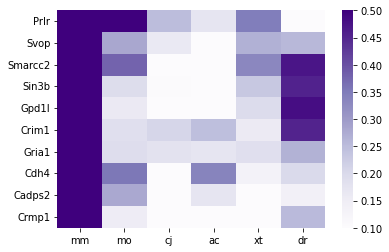

In [101]:
ax = sns.heatmap(df_corr_order, cmap = 'Purples', vmax = .5, vmin = 0.1)
ax.set_facecolor('grey')
plt.savefig('../../Figures/Figures_08022026/3E_Pgr_Ar_downstream_scenic_noTF_08032026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_08022026/3E_Pgr_Ar_downstream_scenic_noTF_08032026.pdf',bbox_inches='tight')

In [182]:
df_corr_order

,mm,mo,cj,ac,xt,dr
Slc32a1,0.571544,0.593239,0.478050,0.626124,0.607228,0.604755
Gad1,0.605130,0.631357,0.423415,0.359381,0.690978,0.705686
Gad2,0.578733,0.772032,0.412538,0.587437,0.543491,0.537991
Grik3,0.538182,0.595121,0.606956,0.488937,0.437412,0.095036
Nrxn3,0.673965,0.580093,0.411048,0.569666,0.658252,0.167690
Ecel1,0.493971,0.615903,0.336678,0.443299,0.222277,0.462666
Actr5,0.728177,0.591403,-0.010721,0.396189,-0.051752,0.082821
Cpne2,0.480285,0.569946,0.087839,0.267320,0.315280,0.114575
Gpc4,0.501951,0.435751,-0.093377,0.064822,-0.054469,NaN
Eif1b,0.495024,0.282341,-0.128826,0.242954,0.283908,0.262114


In [183]:
df_corr_order.to_csv('../../Figures/Figures_07242026/3E_Isl1_Dlx2_downstream_scenic_noTF_07272026.csv')

In [ ]:
#checking regulation

In [152]:
df_corr_order = pd.read_csv('Figures/Figures_07072026/3F_Dlx_Isl1_downstream_scenic_noTF_07072026.csv',index_col = 'Unnamed: 0')

In [154]:
df_corr_order.index

Index(['Slc32a1', 'Gad1', 'Gad2', 'Grik3', 'Nrxn3', 'Ecel1', 'Actr5', 'Cpne2',
       'Gpc4', 'Eif1b'],
      dtype='object')

In [103]:
g_mapping = pd.DataFrame(data = [dlx_list,
                     [mo_exp[i] for i in dlx_list],
                     [cj_exp[i] for i in dlx_list],
                     [ac_exp[i] for i in dlx_list],
                     [xt_exp[i] for i in dlx_list],
                     [dr_exp[i] for i in dlx_list]],
             index = ['Mouse name','Vole name','Quail name','Anole name','Xenopus name','Zebrafish name']).T

In [104]:
g_mapping

,Mouse name,Vole name,Quail name,Anole name,Xenopus name,Zebrafish name
0,Slc32a1,Slc32a1,SLC32A1,slc32a1,slc32a1,slc32a1
1,Gad1,Gad1,GAD1,gad1,gad1.1,gad1b
2,Gad2,Gad2,GAD2,gad2,gad2,gad2
3,Grik3,Grik3,GRIK3,grik3,grik3,grik3
4,Nrxn3,Nrxn3,NRXN3,nrxn3,nrxn3,nrxn3a
5,Ecel1,Ecel1,ECEL1,ecel1,ecel1,ecel1
6,Actr5,Actr5,ACTR5,actr5,actr5,actr5
7,Abat,Abat,ABAT,abat,NaN,abat
8,Gpc4,Gpc4,GPC4,gpc4,gpc4,gpc4
9,Eif1b,ENSMOCG00000000649,EIF1B,eif1b,eif1b,eif1b


In [240]:
neb = ['Tmem163','Slc17a6','Dpf3','Nrn1','Adora1','Cxxc5','Chst8','Samd3','Cacna2d1','F13a1','Fras1','Mrps15','Epb41l4a','Ly75','Tmem229b']
ntcf = ['St18','Nfia','Nfib','Zfp536','Chd7','Adamtsl3','Mcm6','S100a16','P2rx7','Dennd2a','Rnf141','Htr3a','Fdxr','Gpd1','Tns3']

In [239]:
for item in neb:
    TFs = set(scenic[scenic['Gene'] == item]['TF'])
    print(item)
    if 'Ebf3' in TFs:
        print('Ebf3')
    if 'Uncx' in TFs:
        print('Uncx')

Tmem163
Uncx
Slc17a6
Uncx
Dpf3
Uncx
Nrn1
Uncx
Adora1
Ebf3
Cxxc5
Uncx
Chst8
Uncx
Samd3
Uncx
Cacna2d1
Uncx
F13a1
Uncx
Fras1
Uncx
Mrps15
Uncx
Epb41l4a
Uncx
Ly75
Uncx
Tmem229b
Uncx


In [243]:
for item in ntcf:
    TFs = set(scenic[scenic['Gene'] == item]['TF'])
    print(item)
    if 'Tcf4' in TFs:
        print('Tcf4')
    if 'Nfix' in TFs:
        print('Nfix')
    print('----')

St18
Nfix
----
Nfia
Tcf4
Nfix
----
Nfib
Tcf4
Nfix
----
Zfp536
Nfix
----
Chd7
Tcf4
Nfix
----
Adamtsl3
Tcf4
----
Mcm6
Tcf4
----
S100a16
Nfix
----
P2rx7
Tcf4
----
Dennd2a
Tcf4
Nfix
----
Rnf141
Nfix
----
Htr3a
Nfix
----
Fdxr
Tcf4
Nfix
----
Gpd1
Nfix
----
Tns3
Tcf4
Nfix
----
